In [100]:
# Import torch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)


2.11.0+cpu
0.26.0+cpu


# 1. Getting a dataset

In [101]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

In [102]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [103]:
dir(train_data)[40:]

['class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [104]:
image, label = train_data[0]
image,label


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [105]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [106]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [107]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [108]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [109]:
train_data.transforms

StandardTransform
Transform: ToTensor()

In [110]:
len(train_data), len(test_data)

(60000, 10000)

### 1.2 Vidualizing data

torch.Size([1, 28, 28])
torch.Size([28, 28, 1])


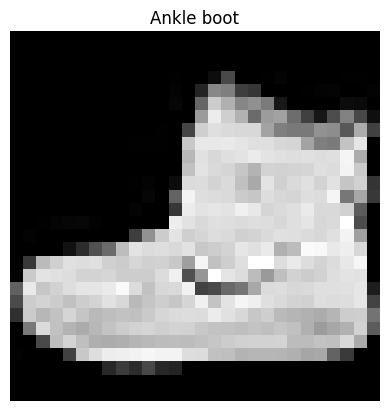

In [111]:
import matplotlib.pyplot as plt

print(image.shape)
print(image.permute((1,2,0)).shape)
# plt.imshow(image.permute((1,2,0)),cmap='gray');
plt.title(train_data.classes[label])
plt.axis(False)
plt.imshow(image.squeeze(),cmap='gray');

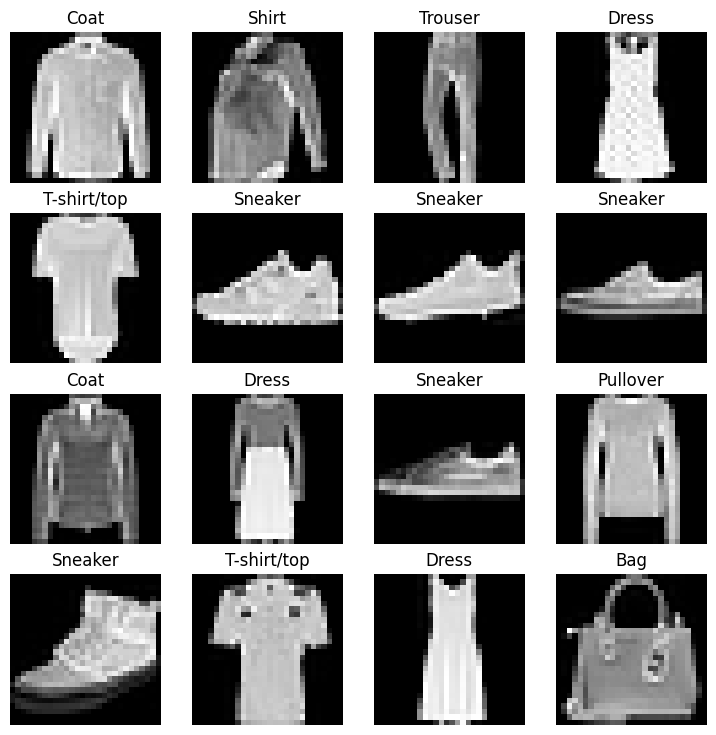

In [112]:
rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(9,9))
for i in range(rows):
    for j in range(cols):
        random_idx = torch.randint(0, len(train_data), size=[1]).item()
        img, label = train_data[random_idx]

        axes[i, j].set_title(train_data.classes[label])
        axes[i, j].axis(False)
        axes[i, j].imshow(img.squeeze(),cmap='gray');

## 2. Prepare DataLoader

DataLoader turns dataset into a Python interable.

In [113]:
from torch.utils.data import DataLoader
# Turn datasets into iterable
train_dataloader = DataLoader(dataset=train_data,
                                    batch_size=32,
                                    shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                                        batch_size=32,
                                        shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1a4e7771a60>,
 <torch.utils.data.dataloader.DataLoader at 0x1a4ed5b9a30>)

In [114]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [115]:
# g
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

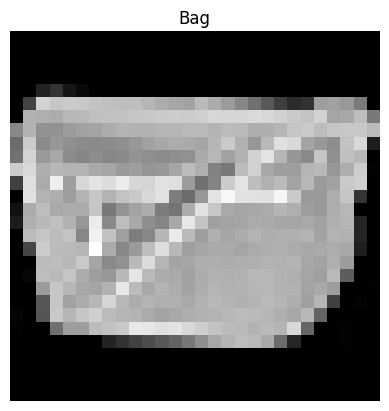

In [116]:
# Visualize sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch),size=[1])
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.title(train_data.classes[label])
plt.axis(False)
plt.imshow(img.squeeze(), cmap='gray');

## 3. Model 0: Build a basline model

Start simply and add complexity when necessary

In [121]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [117]:
# Create a flatten 
flatten_model = nn.Flatten()

x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [118]:
output = flatten_model(x)
output.shape

torch.Size([1, 784])

In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, 
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                        out_features=hidden_units),
            nn.ReLU()
            nn.Linear(in_features=hidden_units,
                        out_features=output_shape)
        )
    
    def forward(self, x:torch.Tensor):
        return self.layer_stack(x)

In [122]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=(28*28),
    hidden_units=10,
    output_shape=len(class_name)
).to(device)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 3.1 Setup loss, Optimizer, Evaluation metrics

In [126]:
from torchmetrics import Accuracy

accuracy_fn = Accuracy(task='multiclass', 
                    num_classes=len(class_name))

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                                lr=0.01)

                              